In [57]:
import math
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

In [58]:
def LCG(a,c,m,x0,n):
  res = []
  x=x0
  for i in range(n-1):
    x = (a*x+c) % m
    res.append(x/m)
  return res

In [59]:
def Logistico(r,x0,n):
  res=[x0]
  for i in range(n-1):
    res.append((res[-1])*r*(1-res[-1]))
  return res

In [72]:
def boxmuller(u1,u2):
  r=math.sqrt(-2*math.log(u1))
  theta = 2*math.pi*u2
  return (r*math.cos(theta),r*math.sin(theta))

def bmList(u,v):
  res = []
  u = np.clip(u,1e-10,1.0)
  for i in range(len(u)):
    bm = boxmuller(u[i],v[i])
    res.append(bm[0])
    res.append(bm[1])
  return res

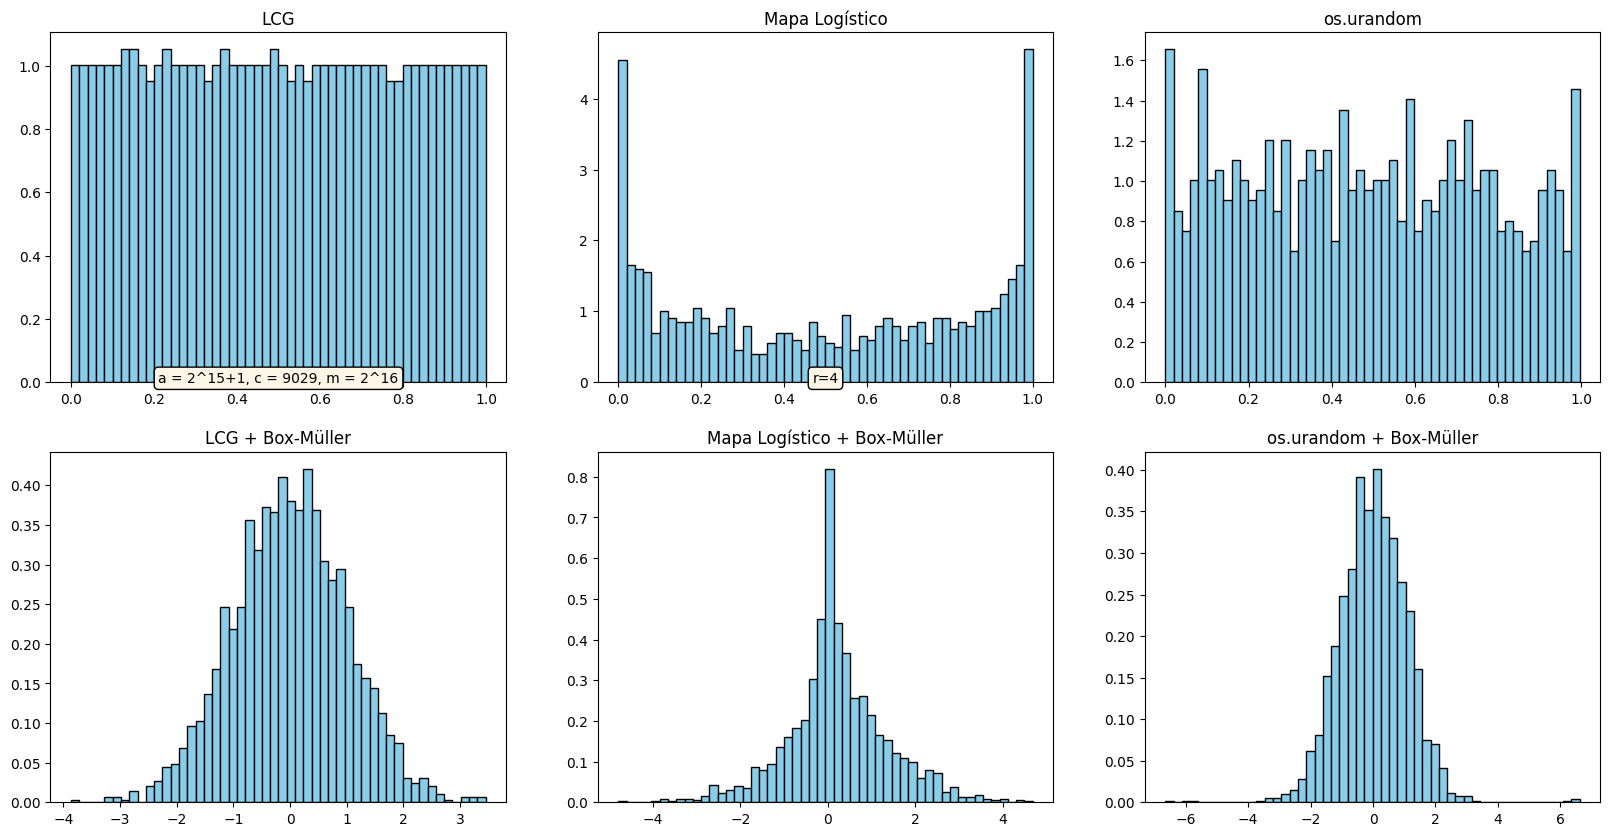

In [86]:
n = 1000

a = 2**15+1
c = 9029
m = 2**16
x0 = 1234

lcg = LCG(a,c,m,x0,n)
lcg2 = LCG(a,c,m,lcg[-1],n)

r = 4
x0 /= m

logistico = Logistico(r,x0,n)
logistico2 = Logistico(r,logistico[-1],n)

aleatorio = [b/256 for b in os.urandom(n)]
aleatorio2 = [b/256 for b in os.urandom(n)]


normLcg = bmList(lcg,lcg2)
normLog = bmList(logistico,logistico2)
normRand = bmList(aleatorio,aleatorio2)


fig, axs = plt.subplots(2,3,figsize=(20,10))

axs[0][0].hist(lcg,bins=50, density=True, color='skyblue',edgecolor='black')
axs[0][0].set_title("LCG")
axs[0][0].text(.5,0,"a = 2^15+1, c = 9029, m = 2^16", ha='center', bbox=dict(boxstyle="round",fc='oldlace'))

axs[1][0].hist(normLcg,bins=50, density=True, color='skyblue',edgecolor='black')
axs[1][0].set_title("LCG + Box-Müller")

axs[0][1].hist(logistico,bins=50, density=True, color='skyblue',edgecolor='black')
axs[0][1].set_title("Mapa Logístico")
axs[0][1].text(.5,0,"r=4", ha='center', bbox=dict(boxstyle="round",fc='oldlace'))

axs[1][1].hist(normLog,bins=50, density=True, color='skyblue',edgecolor='black')
axs[1][1].set_title("Mapa Logístico + Box-Müller")

axs[0][2].hist(aleatorio,bins=50, density=True, color='skyblue',edgecolor='black')
axs[0][2].set_title("os.urandom")

axs[1][2].hist(normRand,bins=50, density=True, color='skyblue',edgecolor='black')
axs[1][2].set_title("os.urandom + Box-Müller")

plt.show()